<a href="https://colab.research.google.com/github/Clover130/EMSC2010-W8-P1/blob/main/EMSC2010_W8_P1_NB2_u8229609.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010-W8-P1-NB2
In this notebook we'll use ```bambi``` to fit different order polynomial functions to a data set. We'll the use model selection criteria to decide which model is the most parsimonious (i.e., doesn't underfit or overfit the data).  Once a model has been selected, we'll sample the posterior probability distributions and see how we can make predictions based on the regression.

```bambi``` is not included in Colab, so we first need to install it.

In [1]:
!pip install bambi #system command to install bambi package

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.9/218.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.6/164.6 kB 8.4 MB/s eta 0:00:00


We can now load the packages we'll need into the memory.

In [2]:
import numpy as np #for working with numerical arrays
import matplotlib.pyplot as plt #for plotting
import bambi as bmb #for automated Bayesian regression
import arviz as az #for analysis of Bayesian models
import pandas as pd #bambi requires us to work with pandas dataframes

Our dataset is made up of copper concentration (in %) with distance along an adit mine (in m).

In [3]:
dist = np.array([0, 0.8,1.0, 1.3, 2.7, 4.5, 5.1, 6.0, 7.2, 8.7,10.2, 11.8, 13.1, 15.2, 16.3, 17.8, 19.7,20.2, 21.1, 24.7, 25.2, 26.3, 28.1, 30.5, 32.0, 35.3, 36.2, 37.7, 38.4, 41.0]) #distance along the mine adit in m
Cu = np.array([0.6767, 0.6433, 0.7033, 0.5933, 0.6433, 0.5400, 0.4300, 0.5833, 0.4100, 0.4967, 0.1667, 0.6200, 0.5100, 0.5700, 0.9000, 0.6000, 0.6367, 0.8867, 0.7767, 1.2000, 0.6600, 1.1367, 1.1233, 1.1933, 1.2333, 1.1267, 1.5567, 2.1067, 1.6000, 2.0333]) #copper concentration in %

Plot the data to provide an initial visualization.

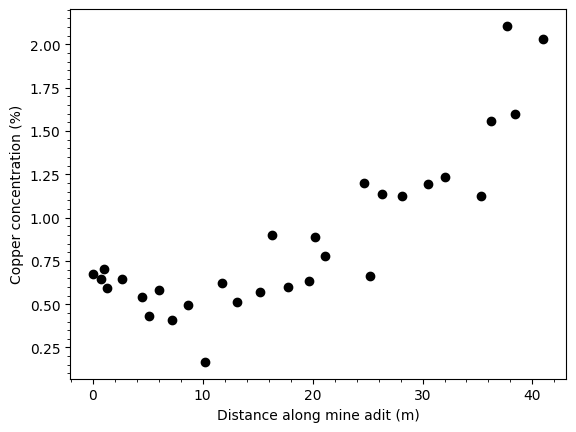

In [4]:
plt.plot(dist,Cu,'ok')
plt.xlabel('Distance along mine adit (m)')
plt.ylabel('Copper concentration (%)')
plt.minorticks_on()

The data doesn't look like a staight-line, so we maybe need to fit a higher-order polynomial. We can fit different models using ```bambi``` and use *selection criteria* to determine which model is the most parsimonious.

Importantly, once we start fitting higher-order polynomials the values of the independent variables can get very large (for example when working with $x^3$ and $x^4$). This can cause problems and ```PyMC``` cannot sample the posteriors reliably.

A solution to this problem is to *scale* the $x$ values so that they have a mean of 0 and a standard deviation of 1. Fitting the model using the scaled $x$ values will normally give a more reliable solution.

First we need to define a dataframe that contains all the variables.

In [5]:
data = pd.DataFrame({"y": Cu}) #define the y-variable
data["x_scaled"] = (dist-np.mean(dist)) / np.std(dist) #scale the x values to have a mean of 0 and stdev of 1
data["x2_scaled"] = data["x_scaled"] ** 2 #used for quadratic regression
data["x3_scaled"] = data["x_scaled"] ** 3 #used for cubic regression
data["x4_scaled"] = data["x_scaled"] ** 4 #used for quartic regression

We can now use ```bambi``` to fit the different candidate models.

Note, that we have to give each model a different name.

Also when fitting the model we use the argument:

```idata_kwargs={"log_likelihood": True}```

This will record extra information that will allow us to compare the models at the end of the analysis.

In [9]:
# Fit a straight-line model (first-order polynomial)
model_linear = bmb.Model("y ~ x_scaled", data)
idata_linear = model_linear.fit(idata_kwargs={"log_likelihood": True}, progressbar=False) # records logarithm of likelihood

# Fit a quadratic model (second-order polynomial)
model_quad = bmb.Model("y ~ x_scaled + x2_scaled", data)
idata_quad = model_quad.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

# Fit a cubic model (third-order polynomial)
model_cubic = bmb.Model("y ~ x_scaled + x2_scaled + x3_scaled", data)
idata_cubic= model_cubic.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

# Fit a quartic model (fourth-order polynomial)
model_quart = bmb.Model("y ~ x_scaled + x2_scaled + x3_scaled + x4_scaled", data)
idata_quart = model_quart.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

### Model comparison
Now that we have calculated each of the polynomial fits, we can compare them using the model selection criteria available in ```arviz```.

In [7]:
# Compare models
comparison = az.compare({
    "linear": idata_linear,
    "quadratic": idata_quad,
    "cubic": idata_cubic,
    "quartic": idata_quart
})
print(comparison) #print the result

           rank  elpd_loo     p_loo  elpd_diff    weight        se       dse  \
quadratic     0  6.244830  4.158999   0.000000  0.668027  4.749444  0.000000   
quartic       1  5.869383  5.532192   0.375447  0.331973  4.847754  1.479194   
cubic         2  5.617296  4.725093   0.627534  0.000000  4.790434  0.524788   
linear        3 -4.687723  3.151836  10.932554  0.000000  4.119807  3.959411   

           warning scale  
quadratic    False   log  
quartic      False   log  
cubic        False   log  
linear       False   log  


The model comparison implies that a quadradtic model is the most appropriate to fit the data.

#### Making predictions from the regression model

We can now use the quadratic regression model to predict how copper concentration changes along the adit.

Using the same approach as in our river gravels example, we can predict both the mean copper concentration and the copper concentration of a future observation.

/tmp/ipykernel_9032/643482915.py:22: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_mean = az.hdi(idata_quad.posterior["mu"].values.reshape(-1, len(x_range)), hdi_prob=0.95)
/tmp/ipykernel_9032/643482915.py:23: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_pps = az.hdi(y_pps_draws, hdi_prob=0.95)


Text(0, 0.5, 'Copper concentration (%)')

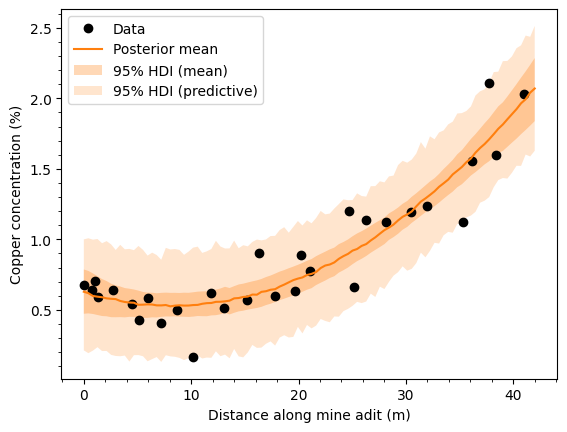

In [8]:
x_range = np.linspace(0, 42, 100) # Predict across a range of distances values from 0 to 40
x_range_scaled = (x_range-np.mean(dist)) / np.std(dist) #we need to apply the same scaling as above

new_data = pd.DataFrame({"x_scaled": x_range_scaled, "x2_scaled": x_range_scaled**2}) #dataframe with the new x-values
model_quad.predict(idata_quad, data=new_data, kind='response_params') #predict the distribution of regression lines at each x-value
model_quad.predict(idata_quad, data=new_data, kind='response') #predict the distribution of gravel size at each x-value

# Make random draws from the posterior of the regression lines
y_mean_draws = idata_quad.posterior["mu"].values

# Reshape to (total_draws, x_points)
y_mean_draws = y_mean_draws.reshape(-1, len(x_range))

# Make random draws from the posterior of the gravel size
y_pps_draws = idata_quad.posterior_predictive["y"].values

# Reshape to (total_draws, x_points)
y_pps_draws = y_pps_draws.reshape(-1, len(x_range))

# Compute mean and HDI of the posterior predictive distribution
posterior_mean = y_pps_draws.mean(axis=0)
hdi_mean = az.hdi(idata_quad.posterior["mu"].values.reshape(-1, len(x_range)), hdi_prob=0.95)
hdi_pps = az.hdi(y_pps_draws, hdi_prob=0.95)

# Plot both posterior for regression lines and the observations
plt.plot(dist, Cu, 'ok', label="Data")
plt.plot(x_range, posterior_mean, color="C1", label="Posterior mean")
plt.fill_between(
    x_range,
    hdi_mean[:, 0],
    hdi_mean[:, 1],
    alpha=0.3,
    color="C1",
    label="95% HDI (mean)",
    edgecolor = None
)

plt.fill_between(
    x_range,
    hdi_pps[:, 0],
    hdi_pps[:, 1],
    alpha=0.2,
    color="C1",
    label="95% HDI (predictive)",
    edgecolor = None
)

plt.legend()
plt.minorticks_on()
plt.xlabel('Distance along mine adit (m)')
plt.ylabel('Copper concentration (%)')

The ```95% HDI (mean)``` band represents the 95% probability envelope for the mean copper concentration at a given distance along the adit.

If we also consider the ```sigma``` posterior distribution that represents deviations in copper concentration away from the regression line, we can make a prediction for future observations.

The ```95% HDI (predictive)``` band represents the 95% probability envelope for the copper concentration of new piece of rock collected at a given distance along the adit.